In [45]:
import os
from pathlib import Path

def encontrar_raiz_repo(marcador=".git"):
    caminho = Path.cwd()
    for pasta in [caminho, *caminho.parents]:
        if (pasta / marcador).exists():
            return pasta
    raise FileNotFoundError(f"Não achei {marcador} subindo a partir de {caminho}")

RAIZ = encontrar_raiz_repo()
print(RAIZ)

/usr/src/myapp


In [49]:
# Processamento de dados
import numpy as np
import pandas as pd
from util import utils as ut

# Graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Modelos de aprendizado de máquina
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score

## Carregando os dados

In [47]:
df_train = pd.read_csv(RAIZ / "data/processed/df_estruturada/df_train.csv", index_col=0)

print(df_train.shape)
df_train.head()

(4926, 11)


,pct_genes_cromossomal_efflux,mdr_score_cromossomal,mdr_score_plasmidial,pct_contigs_plasmidial,pct_plasmidial_amr,pct_plasmidial_conjugacao_amr,n_proviruses_por_mb,gc_diff_plasmid_cromossomo,virulence_score_cromossomal,virulence_score_plasmidial,cat_plasmidial_beta-lactam
sample,,,,,,,,,,,
GCA_021009385.1,7.142857,13,3,11.818182,30.769231,0.000000,1.662461,0.33,6,4,0
GCA_015825355.1,12.500000,3,0,1.666667,0.000000,0.000000,0.942911,-6.27,6,0,0
GCA_038594105.1,1.785714,12,7,14.925373,10.000000,3.333333,0.842382,-1.08,8,3,1
GCA_019201995.1,1.785714,14,5,21.487603,7.692308,0.000000,1.323753,-1.00,8,2,0
GCA_038066875.1,25.000000,4,3,25.668449,4.166667,0.000000,0.841943,-0.31,3,1,0


In [77]:
metadata_cols = pd.read_csv(RAIZ / "data/processed/metadata_filtrada.csv")

metadata_cols = metadata_cols.set_index('sample')
metadata_cols.head()

,Species,Source,Date,Location,BioSample,Estado,Região,source_type,WHO_Priority
sample,,,,,,,,,
GCA_000216055.2,Leptospira interrogans,Homo sapiens,NaN,Salvador,SAMN00254327,BA,Nordeste,Other,Other
GCA_000316425.1,Escherichia coli,NaN,1990.0,Brazil,SAMN01041333,NaN,NaN,Unknown,Critical
GCA_000223095.2,Vibrio cholerae,patient with cholera-like diarrhea,1991.0,NaN,SAMN02470783,NaN,NaN,Gastrointestinal,Other
GCA_036761135.1,Acinetobacter bereziniae,Rectal Swab,2019.0,Brazil,SAMN39408214,NaN,NaN,Gastrointestinal,Other
GCA_003670255.1,Acinetobacter bereziniae,Endotracheal aspirate,2014.0,"Londrina, PR",SAMN09907131,PR,Sul,Respiratory,Other


In [78]:
metadata_alinhado = metadata_cols.loc[df_train.index]

print(metadata_alinhado.shape)
metadata_alinhado.head()

(4926, 9)


,Species,Source,Date,Location,BioSample,Estado,Região,source_type,WHO_Priority
sample,,,,,,,,,
GCA_021009385.1,Staphylococcus aureus,Nasal Colonization,2016.0,Rio de Janeiro,SAMN16946800,RJ,Sudeste,Respiratory,High
GCA_015825355.1,Neisseria meningitidis,cerebrospinal fluid,2016.0,"Sao Paulo, Sao Paulo",SAMN10873099,SP,Sul,CNS,Other
GCA_038594105.1,Pseudomonas aeruginosa,Surveillance swab,2023.0,"Sao Paulo, Sao Paulo",SAMN40996642,SP,Sul,Other,High
GCA_019201995.1,Escherichia coli,urine,2014.0,Uberlandia,SAMN14464882,NaN,NaN,Urinary,Critical
GCA_038066875.1,Burkholderia contaminans,blood,2023.0,Sao Paulo,SAMN40603088,SP,Sul,Blood,Other


## K-means

### Transformações

In [119]:
colunas_X = ['pct_genes_cromossomal_efflux', 'mdr_score_cromossomal',
       'mdr_score_plasmidial', 'pct_contigs_plasmidial', 'pct_plasmidial_amr',
       'pct_plasmidial_conjugacao_amr', 'n_proviruses_por_mb',
       'gc_diff_plasmid_cromossomo', 'virulence_score_cromossomal',
       'virulence_score_plasmidial', 'cat_plasmidial_beta-lactam']

X_base = df_train[colunas_X]

transformacoes = {
    "Sem scaling": X_base.values,
    "StandardScaler": StandardScaler().fit_transform(X_base),
    "MinMaxScaler": MinMaxScaler().fit_transform(X_base),
}

### Elbow Method

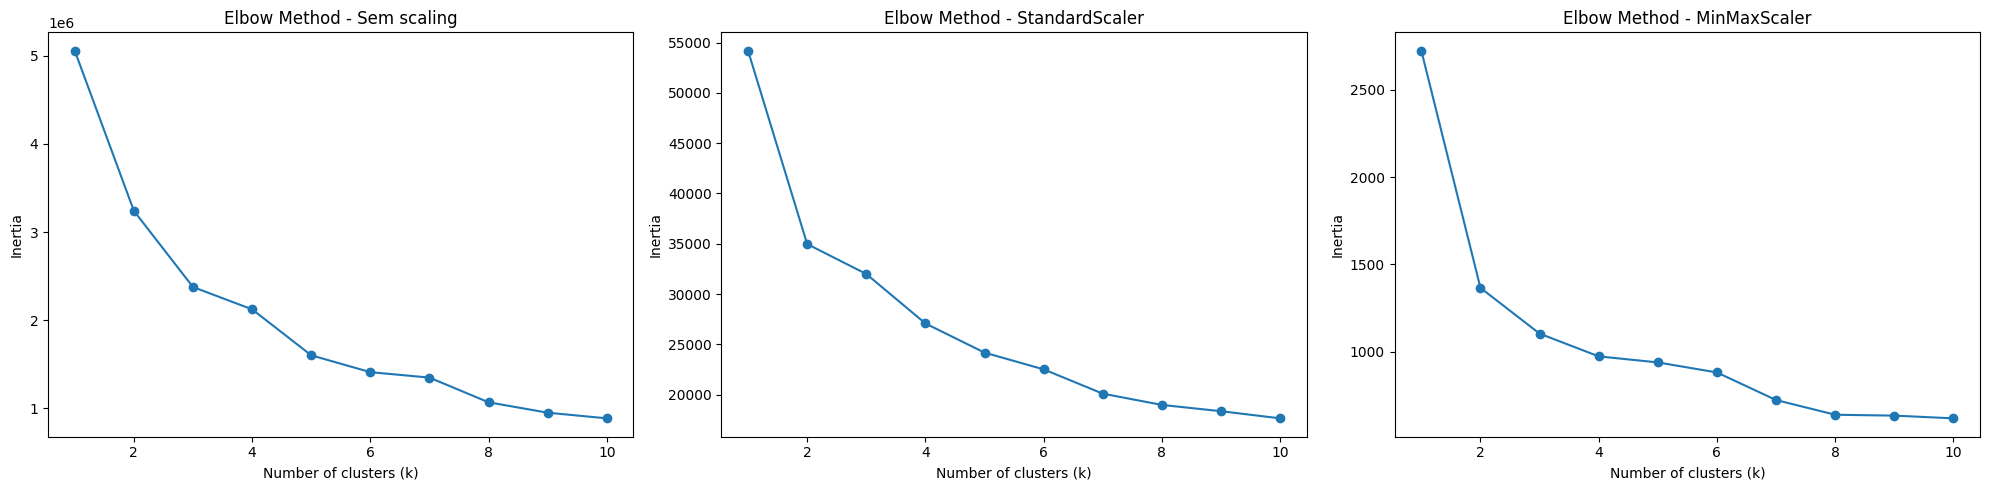

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (nome, X) in zip(axes, transformacoes.items()):
    inertia = []
    for k in range(1, 11):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)

    ax.plot(range(1, 11), inertia, marker="o")
    ax.set_xlabel("Number of clusters (k)")
    ax.set_ylabel("Inertia")
    ax.set_title(f"Elbow Method - {nome}")

plt.tight_layout()
plt.show()

### Silhueta

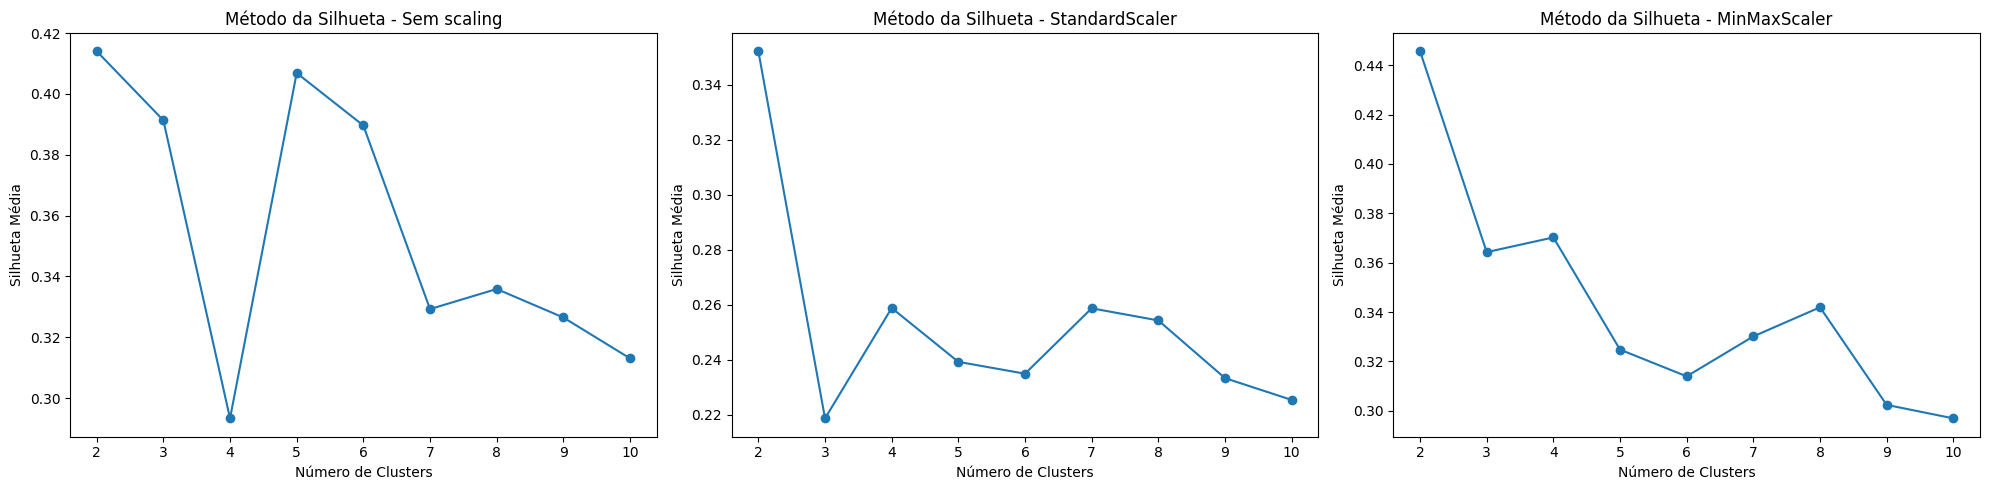

In [122]:
resultados_silueta = {}
max_clusters = 10

for nome, X in transformacoes.items():
    siluetas = []
    for n_clusters in range(2, max_clusters + 1):
        km = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit(X)
        siluetas.append(silhouette_score(X, km.labels_))
    resultados_silueta[nome] = siluetas

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (nome, siluetas) in zip(axes, resultados_silueta.items()):
    ax.plot(range(2, max_clusters + 1), siluetas, marker="o")
    ax.set_xlabel("Número de Clusters")
    ax.set_ylabel("Silhueta Média")
    ax.set_title(f"Método da Silhueta - {nome}")

plt.tight_layout()
plt.show()

### Rodando o algoritmo e visualizando com PCA (pq tenho mais do que 1 coluna de X)

In [123]:
top_especies = metadata_alinhado["Species"].value_counts().nlargest(10).index

top_especies

Index(['Klebsiella pneumoniae', 'Salmonella enterica', 'Escherichia coli',
       'Bacillota bacterium', 'Neisseria gonorrhoeae', 'Staphylococcus aureus',
       'Streptococcus pneumoniae', 'Pseudomonas aeruginosa',
       'Acinetobacter baumannii', 'Neisseria meningitidis'],
      dtype='object')

In [124]:
especie_plot_completo = metadata_alinhado["Species"].where(
    metadata_alinhado["Species"].isin(top_especies), "Outras"
)

especie_plot_completo.head()

sample
GCA_021009385.1     Staphylococcus aureus
GCA_015825355.1    Neisseria meningitidis
GCA_038594105.1    Pseudomonas aeruginosa
GCA_019201995.1          Escherichia coli
GCA_038066875.1                    Outras
Name: Species, dtype: object

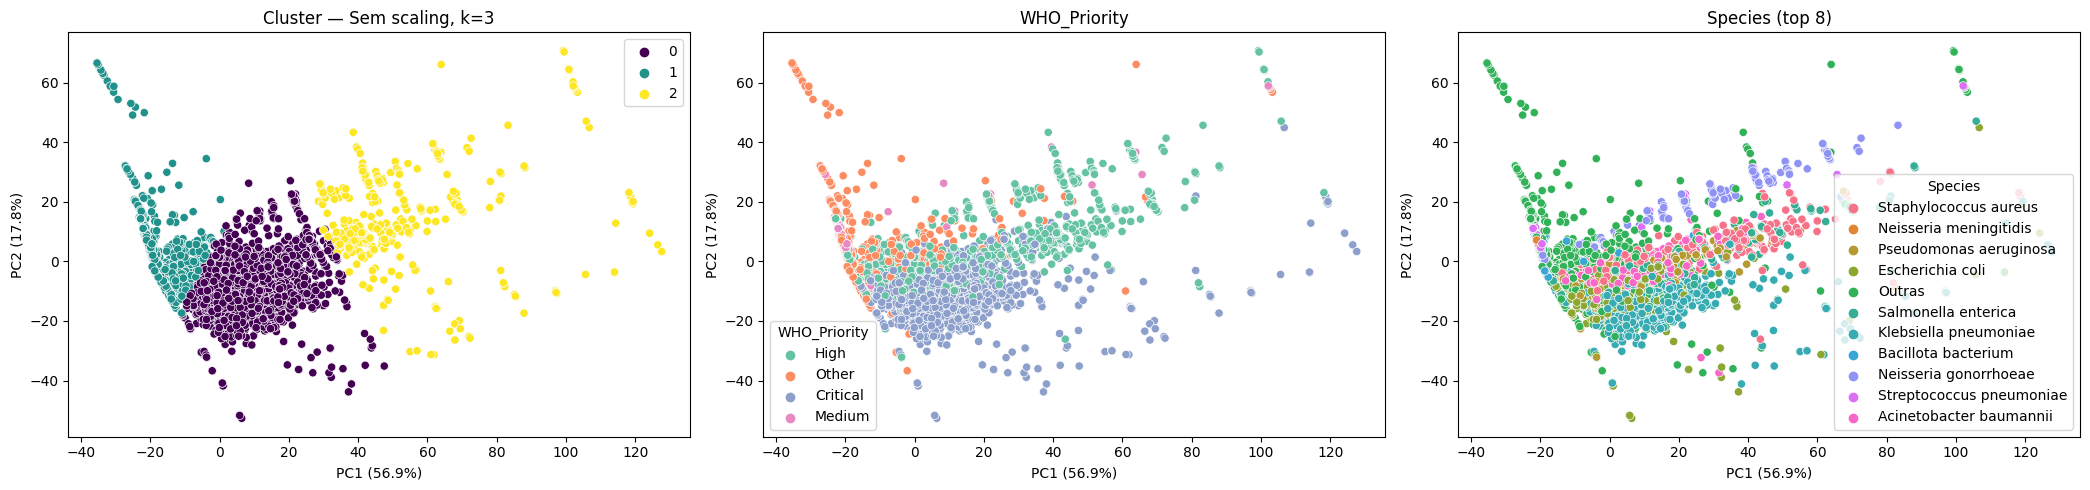

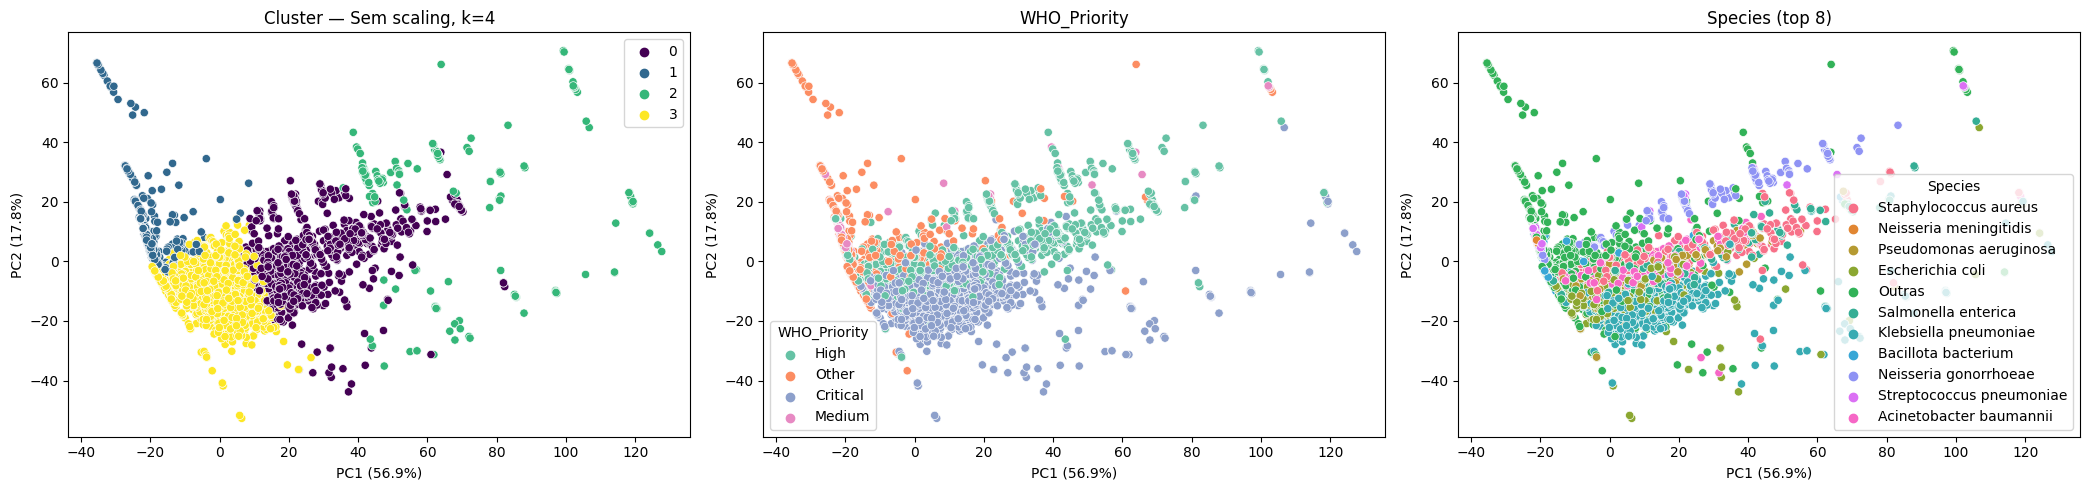

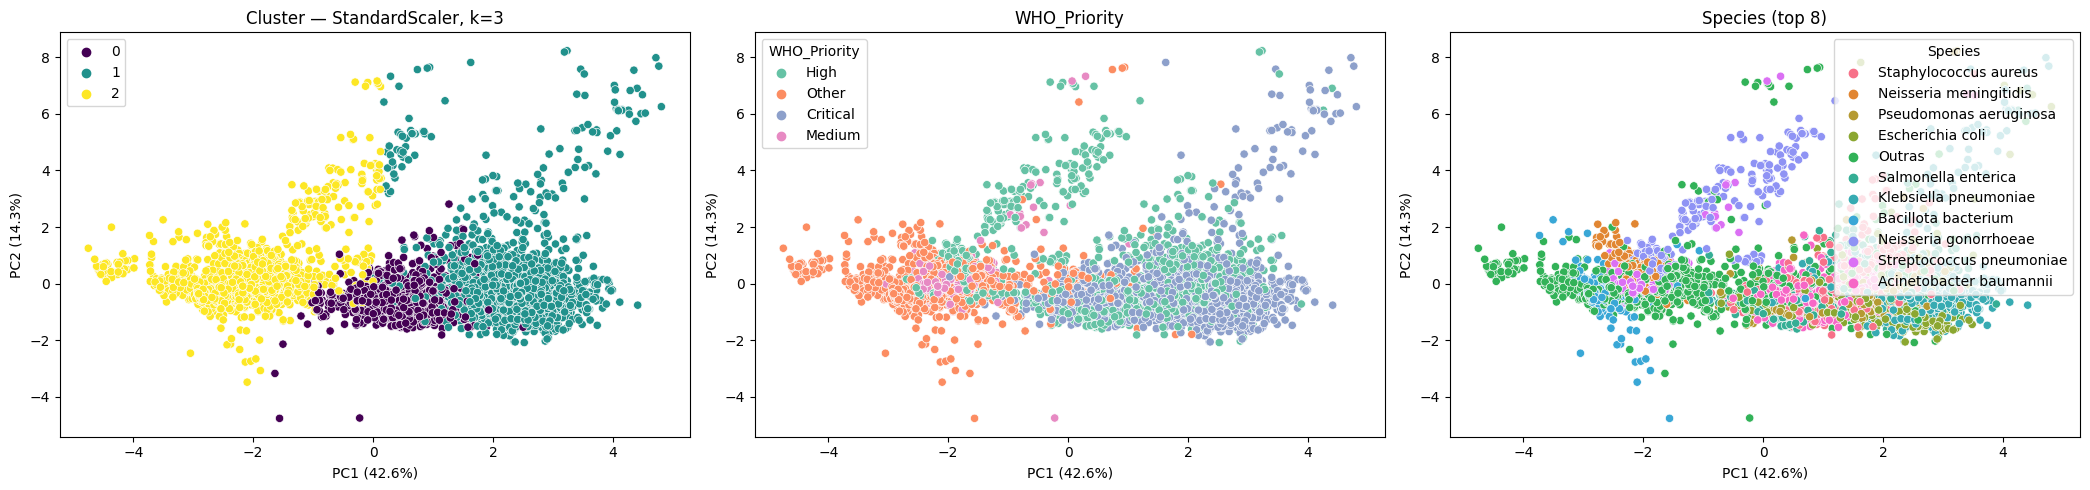

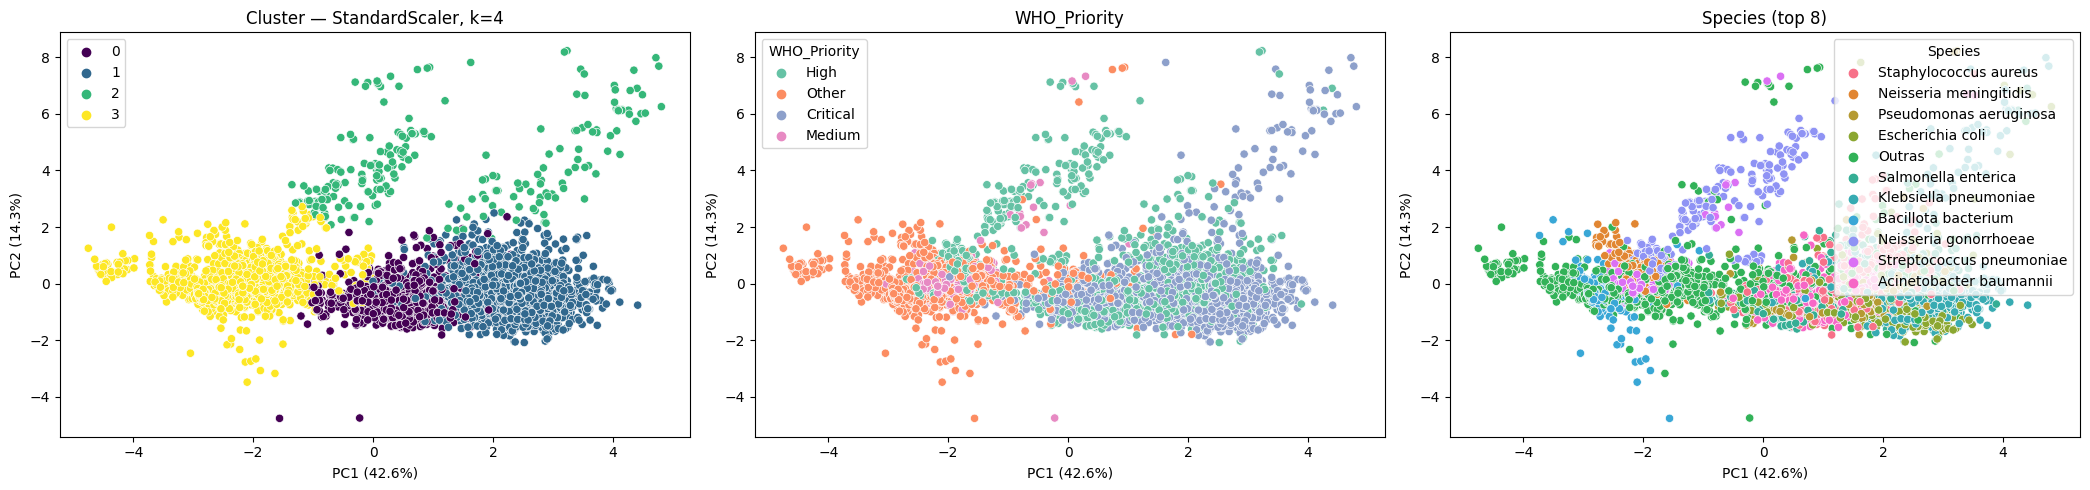

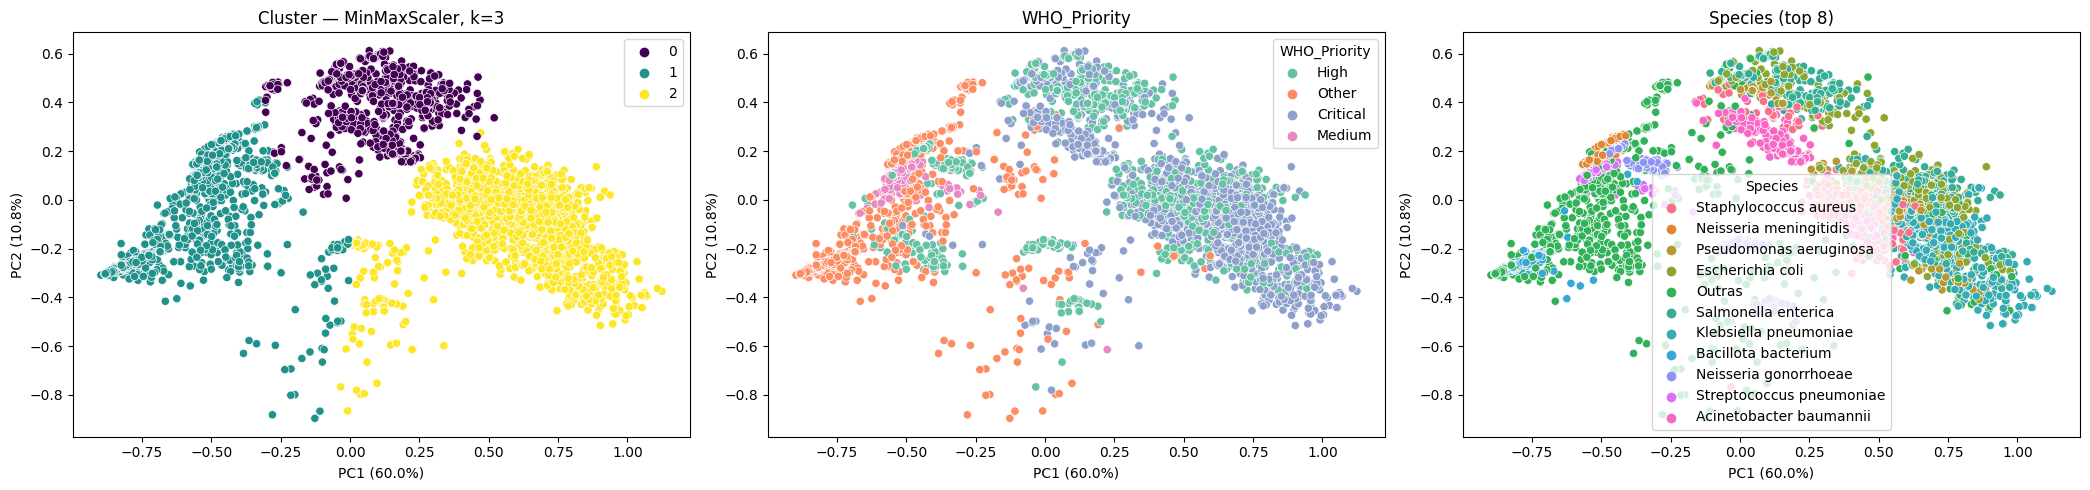

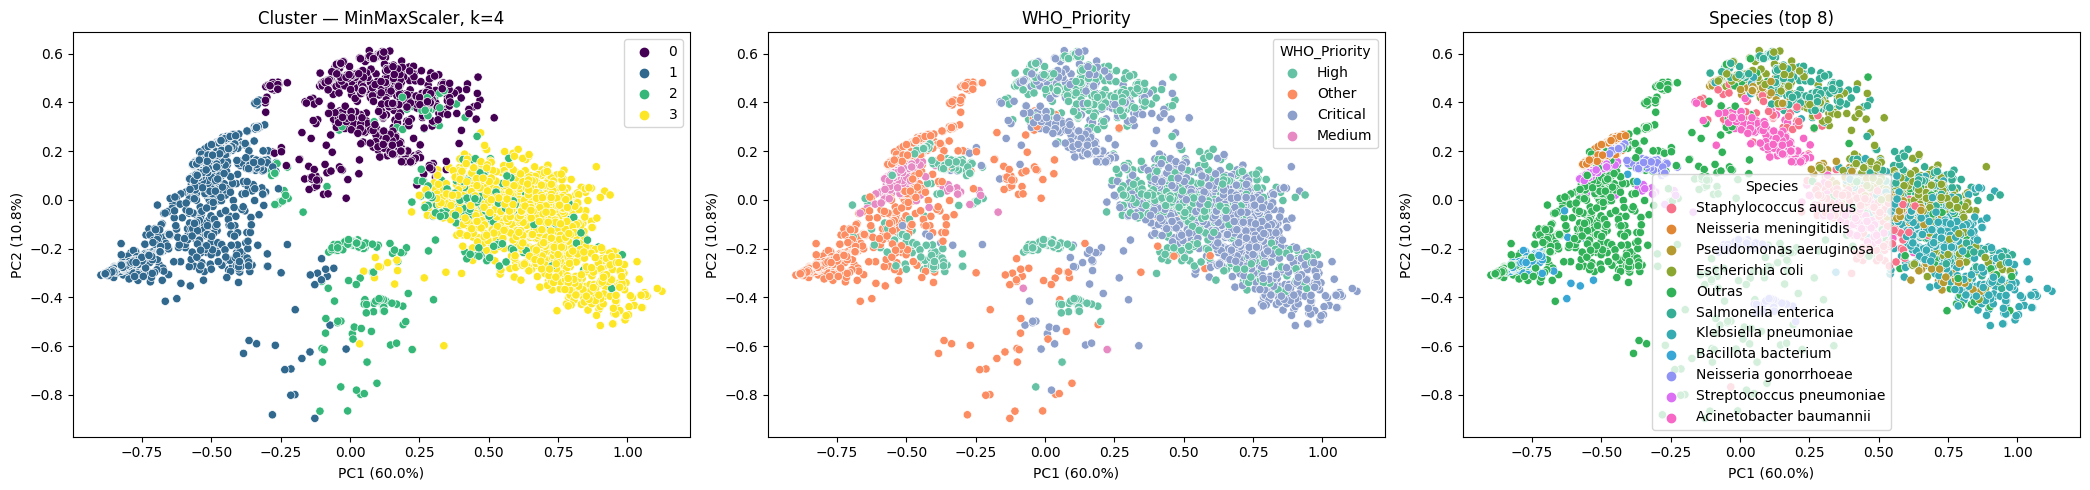

In [125]:
# nome = colunas X (normal ou transformado)
# X = array contendo as colunas X

for nome, X in transformacoes.items():
    for k in range(3, 5):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)

        # Já que meu clustering tem 11 colunas, PCA pra plotar  
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)  

        fig, axes = plt.subplots(1, 3, figsize=(21, 5))

        # PLOT 1 - Cluster coloridos pelo 'label' 
        sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette="viridis", ax=axes[0])
        axes[0].set_title(f"Cluster — {nome}, k={k}")

        # PLOT 2 - Cluster coloridos por 'WHO_Priority' 
        sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=metadata_alinhado["WHO_Priority"], palette="Set2", ax=axes[1])
        axes[1].set_title("WHO_Priority")

        # PLOT 3 - Colorido por espécie (top 10)
        sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=especie_plot_completo, ax=axes[2])
        axes[2].set_title("Species (top 8)")

        for ax in axes:
            ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
            ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

        plt.tight_layout()
        plt.show()

### Métricas

In [126]:
def calcular_metricas(X, labels, nome: str = "") -> dict:
    """
    Calcula métricas intrínsecas de avaliação de clustering (não precisam
    de rótulo verdadeiro conhecido — só a estrutura geométrica).
        Parâmetros:
            X: array-like -> dados usados no clustering (qualquer nº de colunas)
            labels: array-like -> rótulos de cluster previstos
            nome: str -> identificador pra print (ex: nome da transformação/k)
        Retorna:
            dict -> métricas calculadas
    """
    print(f"Calculando métricas para: {nome}\n")

    ss = round(silhouette_score(X, labels), 3)
    print(f"Silhouette Score -> {ss}")

    chs = round(calinski_harabasz_score(X, labels), 3)
    print(f"Calinski Harabasz Score -> {chs}")

    dbs = round(davies_bouldin_score(X, labels), 3)
    print(f"Davies Bouldin Score -> {dbs}")

    return {"silhouette": ss, "calinski_harabasz": chs, "davies_bouldin": dbs}

In [127]:
resultados_metricas = []

for nome, X in transformacoes.items():
    print("========================")
    print(nome)
    for k in range(3, 7):
        
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)

        metricas = calcular_metricas(X, labels, nome=f"{nome} — k={k}")

        metricas.update({"transformacao": nome, "k": k})

        resultados_metricas.append(metricas)

Sem scaling
Calculando métricas para: Sem scaling — k=3

Silhouette Score -> 0.391
Calinski Harabasz Score -> 2776.276
Davies Bouldin Score -> 1.045
Calculando métricas para: Sem scaling — k=4

Silhouette Score -> 0.293
Calinski Harabasz Score -> 2266.323
Davies Bouldin Score -> 1.105
Calculando métricas para: Sem scaling — k=5

Silhouette Score -> 0.407
Calinski Harabasz Score -> 2652.447
Davies Bouldin Score -> 0.91
Calculando métricas para: Sem scaling — k=6

Silhouette Score -> 0.39
Calinski Harabasz Score -> 2542.619
Davies Bouldin Score -> 0.976
StandardScaler
Calculando métricas para: StandardScaler — k=3

Silhouette Score -> 0.219
Calinski Harabasz Score -> 1706.767
Davies Bouldin Score -> 1.688
Calculando métricas para: StandardScaler — k=4

Silhouette Score -> 0.259
Calinski Harabasz Score -> 1641.744
Davies Bouldin Score -> 1.459
Calculando métricas para: StandardScaler — k=5

Silhouette Score -> 0.239
Calinski Harabasz Score -> 1526.026
Davies Bouldin Score -> 1.507
Calcula

In [128]:
df_resultados = pd.DataFrame(resultados_metricas)

df_resultados.head()

,silhouette,calinski_harabasz,davies_bouldin,transformacao,k
0,0.391,2776.276,1.045,Sem scaling,3
1,0.293,2266.323,1.105,Sem scaling,4
2,0.407,2652.447,0.910,Sem scaling,5
3,0.390,2542.619,0.976,Sem scaling,6
4,0.219,1706.767,1.688,StandardScaler,3


In [129]:
df_resultados.sort_values("silhouette", ascending=False).head()

,silhouette,calinski_harabasz,davies_bouldin,transformacao,k
2,0.407,2652.447,0.910,Sem scaling,5
0,0.391,2776.276,1.045,Sem scaling,3
3,0.390,2542.619,0.976,Sem scaling,6
9,0.370,2949.156,1.377,MinMaxScaler,4
8,0.364,3611.313,1.149,MinMaxScaler,3


In [130]:
df_resultados.sort_values("calinski_harabasz", ascending=False).head()

,silhouette,calinski_harabasz,davies_bouldin,transformacao,k
8,0.364,3611.313,1.149,MinMaxScaler,3
9,0.370,2949.156,1.377,MinMaxScaler,4
0,0.391,2776.276,1.045,Sem scaling,3
2,0.407,2652.447,0.910,Sem scaling,5
3,0.390,2542.619,0.976,Sem scaling,6


In [131]:
df_resultados.sort_values("davies_bouldin", ascending=True).head()  # menor é melhor nessa

,silhouette,calinski_harabasz,davies_bouldin,transformacao,k
2,0.407,2652.447,0.910,Sem scaling,5
3,0.390,2542.619,0.976,Sem scaling,6
0,0.391,2776.276,1.045,Sem scaling,3
1,0.293,2266.323,1.105,Sem scaling,4
8,0.364,3611.313,1.149,MinMaxScaler,3


## Melhores (com base nos gráficos e métricas)
- Sem scaling 5
- MinMaxScaler 3/4

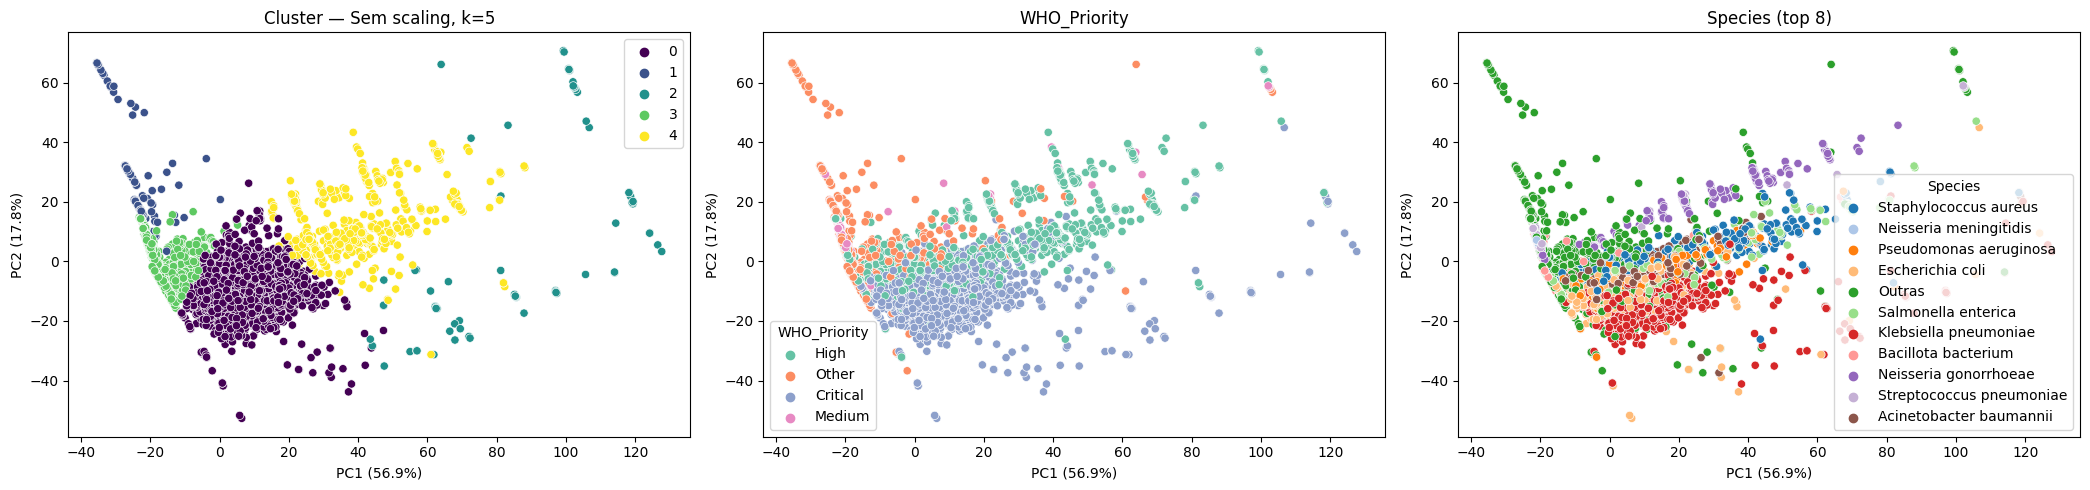

In [136]:
# nome = colunas X (normal ou transformado)
# X = array contendo as colunas X

for nome, X in transformacoes.items():

    if nome == "Sem scaling":
        k = 5
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)
         
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)  
        
        fig, axes = plt.subplots(1, 3, figsize=(21, 5))
        
        # PLOT 1 - Cluster coloridos pelo 'label' 
        sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette="viridis", ax=axes[0])
        axes[0].set_title(f"Cluster — {nome}, k={k}")
        
        # PLOT 2 - Cluster coloridos por 'WHO_Priority' 
        sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=metadata_alinhado["WHO_Priority"], palette="Set2", ax=axes[1])
        axes[1].set_title("WHO_Priority")
        
        # PLOT 3 - Colorido por espécie (top 10)
        sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=especie_plot_completo, palette="tab20", ax=axes[2])
        axes[2].set_title("Species (top 8)")

        for ax in axes:
            ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
            ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
        
        plt.tight_layout()
        plt.show()


### Colorindo por colunas mais interessantes

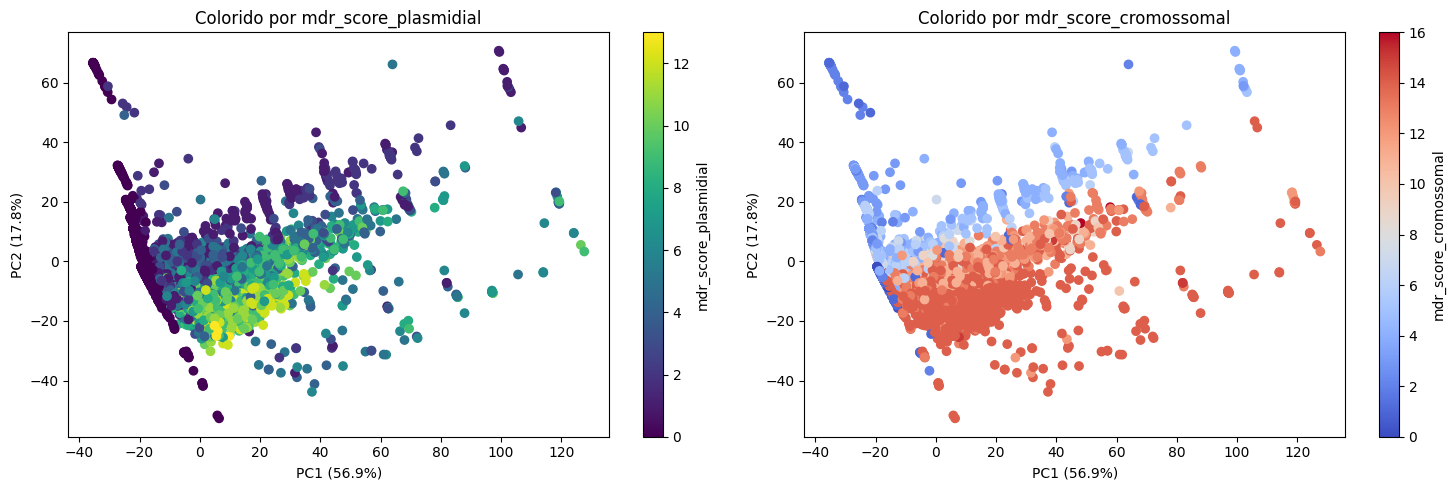

In [140]:
# nome = colunas X (normal ou transformado)
# X = array contendo as colunas X

for nome, X in transformacoes.items():

    if nome == "Sem scaling":
        k = 5
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)
         
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)  
        
        ffig, axes = plt.subplots(1, 2, figsize=(15, 5))

        sc1 = axes[0].scatter(
            X_pca[:,0], X_pca[:,1],
            c=df_train["mdr_score_plasmidial"], cmap="viridis"
        )
        axes[0].set_title("Colorido por mdr_score_plasmidial")
        fig.colorbar(sc1, ax=axes[0], label="mdr_score_plasmidial")

        sc2 = axes[1].scatter(
            X_pca[:,0], X_pca[:,1],
            c=df_train["mdr_score_cromossomal"], cmap="coolwarm"
        )
        axes[1].set_title("Colorido por mdr_score_cromossomal")
        fig.colorbar(sc2, ax=axes[1], label="mdr_score_cromossomal")

        for ax in axes:
            ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
            ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

        plt.tight_layout()
        plt.show()

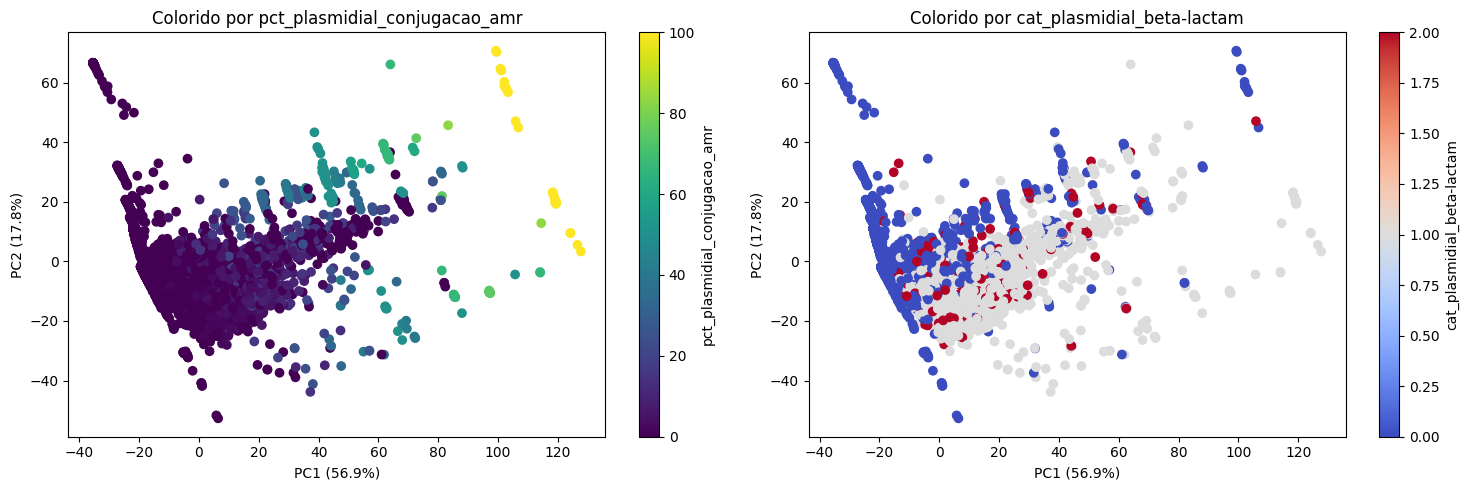

In [141]:
# nome = colunas X (normal ou transformado)
# X = array contendo as colunas X

for nome, X in transformacoes.items():

    if nome == "Sem scaling":
        k = 5
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)
         
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)  
        
        ffig, axes = plt.subplots(1, 2, figsize=(15, 5))

        sc1 = axes[0].scatter(
            X_pca[:,0], X_pca[:,1],
            c=df_train["pct_plasmidial_conjugacao_amr"], cmap="viridis"
        )
        axes[0].set_title("Colorido por pct_plasmidial_conjugacao_amr")
        fig.colorbar(sc1, ax=axes[0], label="pct_plasmidial_conjugacao_amr")

        sc2 = axes[1].scatter(
            X_pca[:,0], X_pca[:,1],
            c=df_train["cat_plasmidial_beta-lactam"], cmap="coolwarm"
        )
        axes[1].set_title("Colorido por cat_plasmidial_beta-lactam")
        fig.colorbar(sc2, ax=axes[1], label="cat_plasmidial_beta-lactam")

        for ax in axes:
            ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
            ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

        plt.tight_layout()
        plt.show()

In [116]:
df_train.head()

,pct_genes_cromossomal_efflux,mdr_score_cromossomal,mdr_score_plasmidial,pct_contigs_plasmidial,pct_plasmidial_amr,pct_plasmidial_conjugacao_amr,n_proviruses_por_mb,gc_diff_plasmid_cromossomo,virulence_score_cromossomal,virulence_score_plasmidial,cat_plasmidial_beta-lactam
sample,,,,,,,,,,,
GCA_021009385.1,7.142857,13,3,11.818182,30.769231,0.000000,1.662461,0.33,6,4,0
GCA_015825355.1,12.500000,3,0,1.666667,0.000000,0.000000,0.942911,-6.27,6,0,0
GCA_038594105.1,1.785714,12,7,14.925373,10.000000,3.333333,0.842382,-1.08,8,3,1
GCA_019201995.1,1.785714,14,5,21.487603,7.692308,0.000000,1.323753,-1.00,8,2,0
GCA_038066875.1,25.000000,4,3,25.668449,4.166667,0.000000,0.841943,-0.31,3,1,0


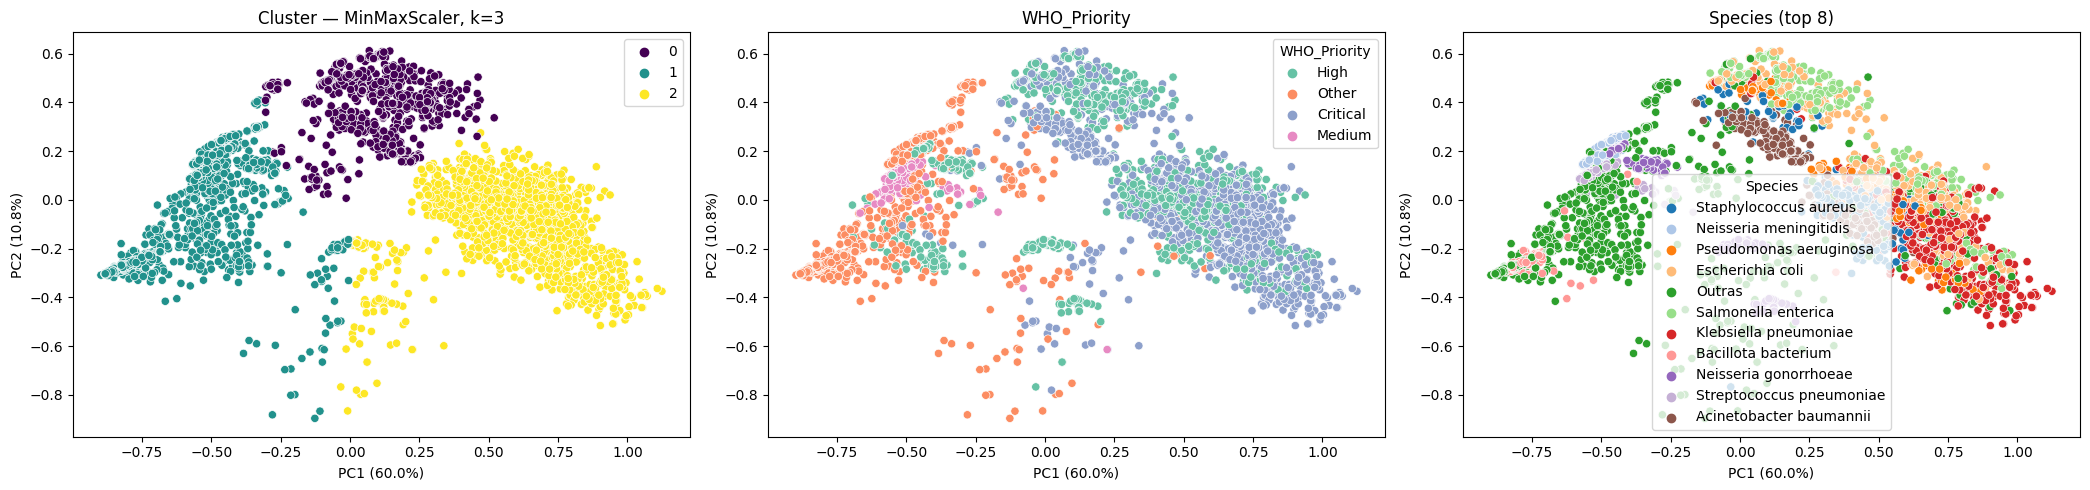

In [148]:
# nome = colunas X (normal ou transformado)
# X = array contendo as colunas X

for nome, X in transformacoes.items():

    if nome == "MinMaxScaler":
        k = 3
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)
         
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)  
        
        fig, axes = plt.subplots(1, 3, figsize=(21, 5))
        
        # PLOT 1 - Cluster coloridos pelo 'label' 
        sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette="viridis", ax=axes[0])
        axes[0].set_title(f"Cluster — {nome}, k={k}")
        
        # PLOT 2 - Cluster coloridos por 'WHO_Priority' 
        sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=metadata_alinhado["WHO_Priority"], palette="Set2", ax=axes[1])
        axes[1].set_title("WHO_Priority")
        
        # PLOT 3 - Colorido por espécie (top 10)
        sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=especie_plot_completo, palette="tab20", ax=axes[2])
        axes[2].set_title("Species (top 8)")

        for ax in axes:
            ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
            ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
        
        plt.tight_layout()
        plt.show()


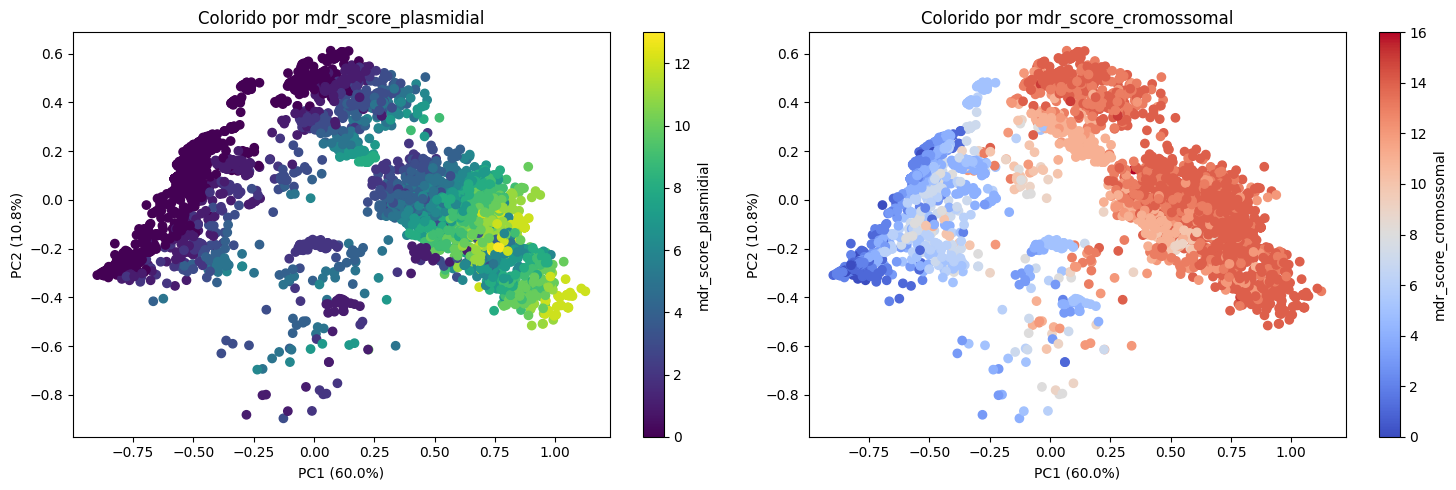

In [149]:
# nome = colunas X (normal ou transformado)
# X = array contendo as colunas X

for nome, X in transformacoes.items():

    if nome == "MinMaxScaler":
        k = 3
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)
         
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)  
        
        ffig, axes = plt.subplots(1, 2, figsize=(15, 5))

        sc1 = axes[0].scatter(
            X_pca[:,0], X_pca[:,1],
            c=df_train["mdr_score_plasmidial"], cmap="viridis"
        )
        axes[0].set_title("Colorido por mdr_score_plasmidial")
        fig.colorbar(sc1, ax=axes[0], label="mdr_score_plasmidial")

        sc2 = axes[1].scatter(
            X_pca[:,0], X_pca[:,1],
            c=df_train["mdr_score_cromossomal"], cmap="coolwarm"
        )
        axes[1].set_title("Colorido por mdr_score_cromossomal")
        fig.colorbar(sc2, ax=axes[1], label="mdr_score_cromossomal")

        for ax in axes:
            ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
            ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

        plt.tight_layout()
        plt.show()

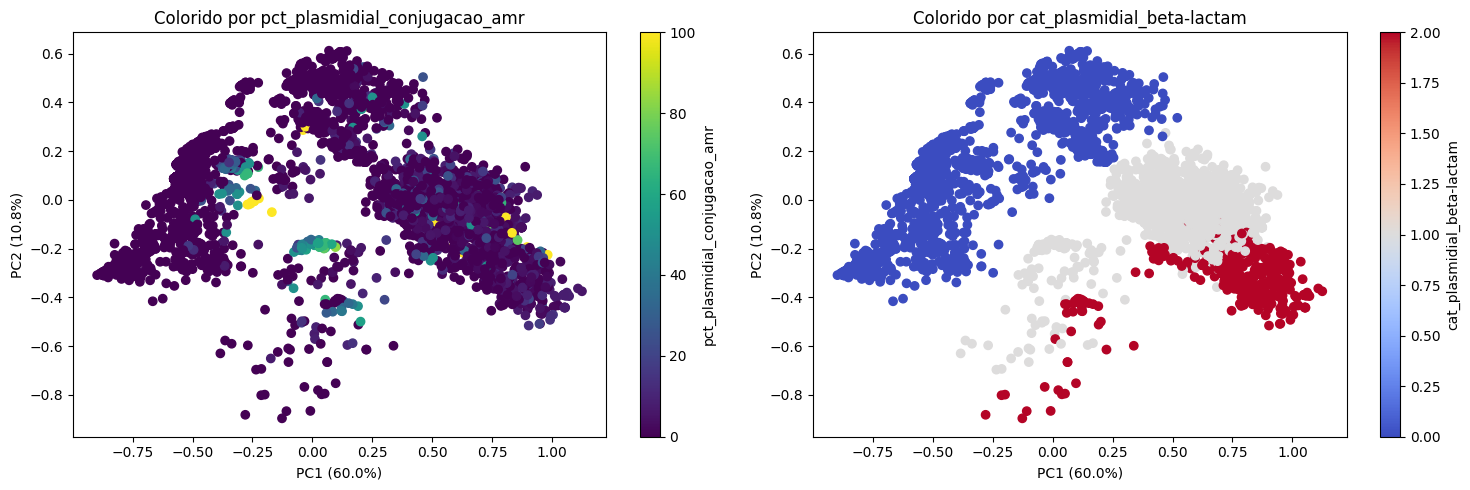

In [150]:
# nome = colunas X (normal ou transformado)
# X = array contendo as colunas X

for nome, X in transformacoes.items():

    if nome == "MinMaxScaler":
        k = 3
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)
         
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)  
        
        ffig, axes = plt.subplots(1, 2, figsize=(15, 5))

        sc1 = axes[0].scatter(
            X_pca[:,0], X_pca[:,1],
            c=df_train["pct_plasmidial_conjugacao_amr"], cmap="viridis"
        )
        axes[0].set_title("Colorido por pct_plasmidial_conjugacao_amr")
        fig.colorbar(sc1, ax=axes[0], label="pct_plasmidial_conjugacao_amr")

        sc2 = axes[1].scatter(
            X_pca[:,0], X_pca[:,1],
            c=df_train["cat_plasmidial_beta-lactam"], cmap="coolwarm"
        )
        axes[1].set_title("Colorido por cat_plasmidial_beta-lactam")
        fig.colorbar(sc2, ax=axes[1], label="cat_plasmidial_beta-lactam")

        for ax in axes:
            ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
            ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

        plt.tight_layout()
        plt.show()